 BASELINE vs HYBRID COMPARISON
   Experiment A: Secondary (UWCD) only
   Experiment B: Primary (custom) only, train split augmented 4x
Device: cuda
 BUILDING DATA — Experiment: secondary_only  (sources=['uwcd'])

 Listing: /kaggle/input/datasets/siddhantmaji/unified-waste-classification-dataset/content/unified_dataset
   metal → metal: 8000 images
   glass → glass: 8000 images
  SKIPPED FOLDER: 'organic_waste' does not match any target class ['plastic', 'metal', 'glass', 'paper', 'cardboard', 'trash'] - check for a naming/casing mismatch if this was unintended.
  SKIPPED FOLDER: 'battery' does not match any target class ['plastic', 'metal', 'glass', 'paper', 'cardboard', 'trash'] - check for a naming/casing mismatch if this was unintended.
   trash → trash: 8000 images
  SKIPPED FOLDER: 'textiles' does not match any target class ['plastic', 'metal', 'glass', 'paper', 'cardboard', 'trash'] - check for a naming/casing mismatch if this was unintended.
   paper_cardboard → paper: 8000 imag

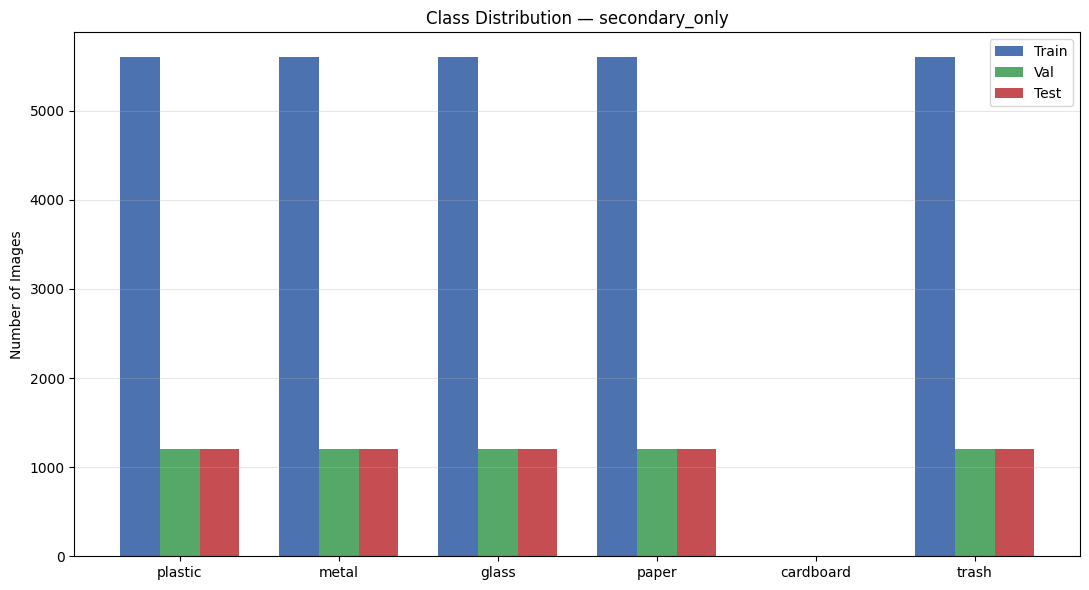

 CNN-only + Fusion (ResNet50)  —  secondary_only
 Resuming secondary_only/cnn_only_fusion from checkpoint...
   Resuming at epoch 11/10 (best_val_acc=97.83%)

 Training CNN-only + Fusion (ResNet50)  [secondary_only]
 cnn_only_fusion [secondary_only] Test Accuracy: 98.20%
  Saved diagnostics for secondary_only_cnn_only_fusion
 ViT-only + Fusion (DeiT-Small)  —  secondary_only
 Resuming secondary_only/vit_only_fusion from checkpoint...
   Resuming at epoch 11/10 (best_val_acc=98.25%)

 Training ViT-only + Fusion (DeiT-Small)  [secondary_only]
 vit_only_fusion [secondary_only] Test Accuracy: 98.57%
  Saved diagnostics for secondary_only_vit_only_fusion
 CNN-ViT Hybrid Fusion (proposed)  —  secondary_only
 Resuming secondary_only/cnn_vit_hybrid_fusion from checkpoint...
   Resuming at epoch 11/10 (best_val_acc=98.22%)

 Training CNN-ViT Hybrid Fusion (proposed)  [secondary_only]
 cnn_vit_hybrid_fusion [secondary_only] Test Accuracy: 98.30%
  Saved diagnostics for secondary_only_cnn_vit_hyb

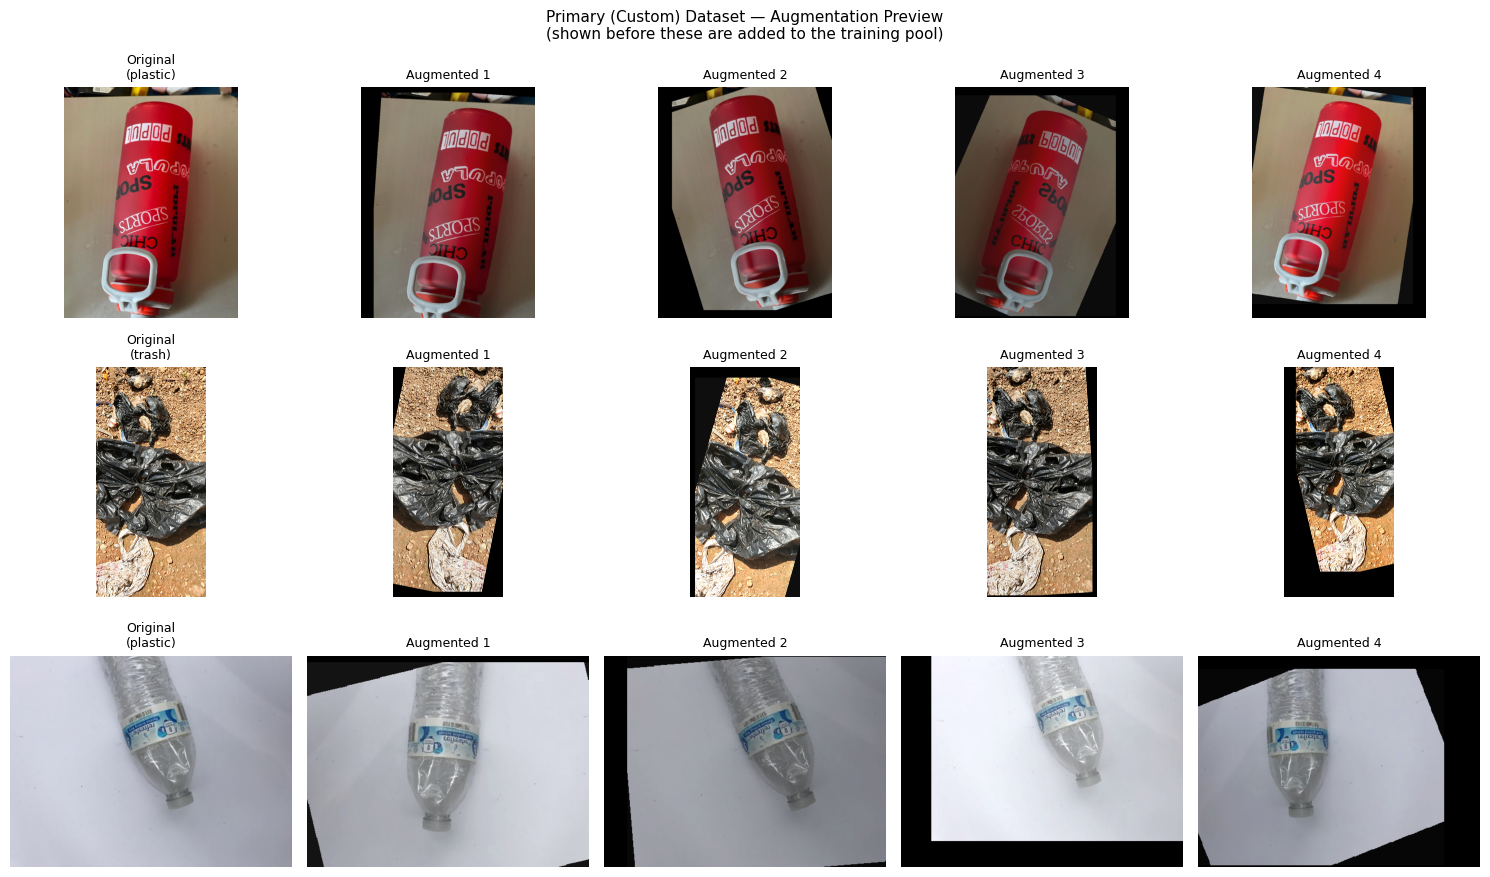


 Generating augmented images for 1262 custom training images...
  Augmented 50/1262 images...
  Augmented 100/1262 images...
  Augmented 150/1262 images...
  Augmented 200/1262 images...
  Augmented 250/1262 images...
  Augmented 300/1262 images...
  Augmented 350/1262 images...
  Augmented 400/1262 images...
  Augmented 450/1262 images...
  Augmented 500/1262 images...
  Augmented 550/1262 images...
  Augmented 600/1262 images...
  Augmented 650/1262 images...
  Augmented 700/1262 images...
  Augmented 750/1262 images...
  Augmented 800/1262 images...
  Augmented 850/1262 images...
  Augmented 900/1262 images...
  Augmented 950/1262 images...
  Augmented 1000/1262 images...
  Augmented 1050/1262 images...
  Augmented 1100/1262 images...
  Augmented 1150/1262 images...
  Augmented 1200/1262 images...
  Augmented 1250/1262 images...
 Generated 5048 augmented images
 Adding 5048 augmented images to the 1262 original custom train images
 Zero-overlap assertion passed

 Final split — trai

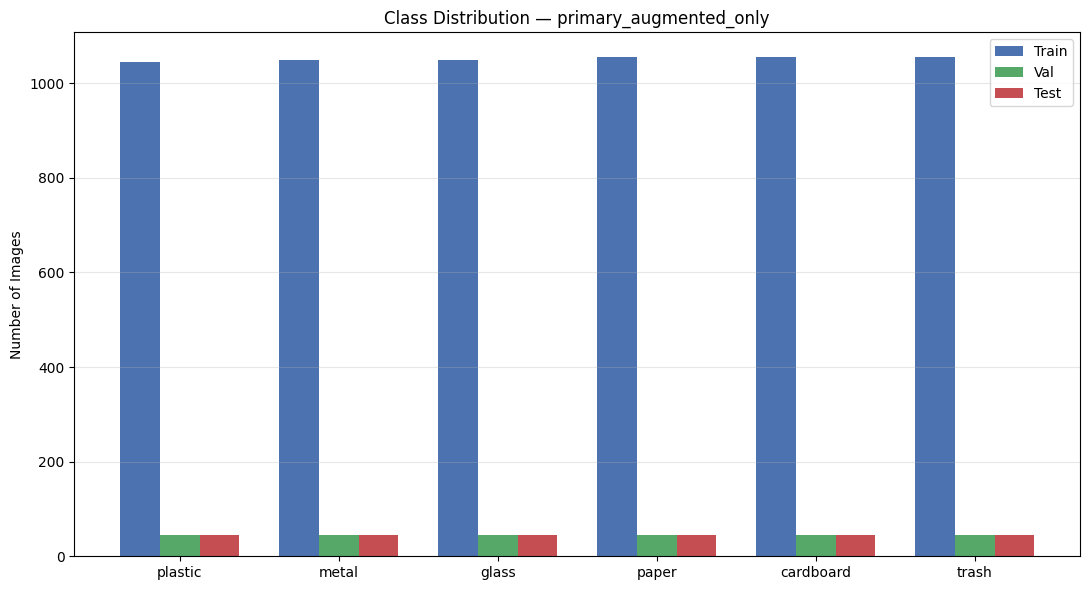

 CNN-only + Fusion (ResNet50)  —  primary_augmented_only

 Training CNN-only + Fusion (ResNet50)  [primary_augmented_only]
  [primary_augmented_only/cnn_only_fusion] Epoch 1/10 | train_loss=0.4334 train_acc=84.93% | val_loss=0.4219 val_acc=88.89%
  [primary_augmented_only/cnn_only_fusion] Epoch 2/10 | train_loss=0.1490 train_acc=94.98% | val_loss=0.2499 val_acc=91.11%
  [primary_augmented_only/cnn_only_fusion] Epoch 3/10 | train_loss=0.0688 train_acc=97.92% | val_loss=0.3148 val_acc=92.59%
  [primary_augmented_only/cnn_only_fusion] Epoch 4/10 | train_loss=0.0425 train_acc=98.65% | val_loss=0.2627 val_acc=94.44%
  [primary_augmented_only/cnn_only_fusion] Epoch 5/10 | train_loss=0.0389 train_acc=98.89% | val_loss=0.3796 val_acc=92.22%
  [primary_augmented_only/cnn_only_fusion] Epoch 6/10 | train_loss=0.0288 train_acc=99.06% | val_loss=0.3164 val_acc=94.07%
 Early stopping at epoch 6 (no val_loss improvement for 4 epochs)
 cnn_only_fusion [primary_augmented_only] Test Accuracy: 94.83%
  S

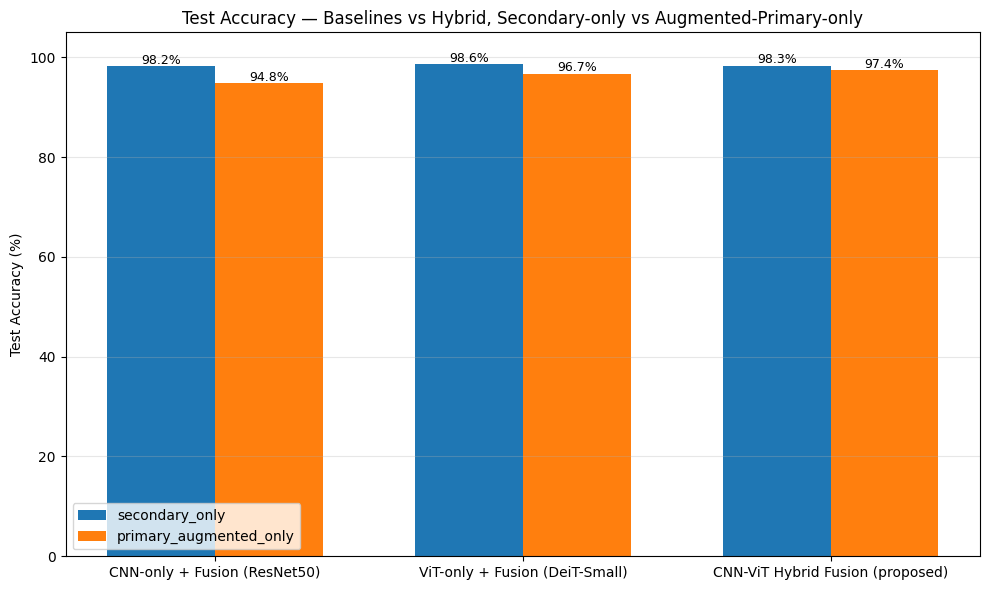

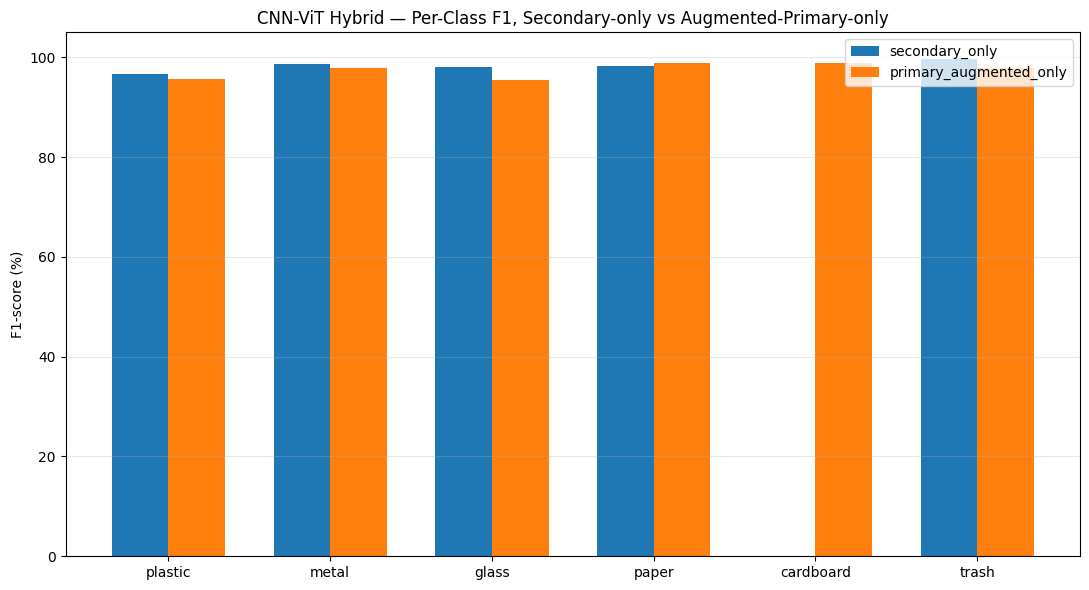


 SUMMARY TABLE
Model                        Experiment               Test Acc   Best Val Acc   Epochs Run
------------------------------------------------------------------------------------------
CNN-only + Fusion (ResNet50) secondary_only           98.20      97.83          10
ViT-only + Fusion (DeiT-Small) secondary_only           98.57      98.25          10
CNN-ViT Hybrid Fusion (proposed) secondary_only           98.30      98.22          10
CNN-only + Fusion (ResNet50) primary_augmented_only   94.83      94.44          6
ViT-only + Fusion (DeiT-Small) primary_augmented_only   96.68      94.81          6
CNN-ViT Hybrid Fusion (proposed) primary_augmented_only   97.42      95.56          9

DONE. All artifacts saved under /kaggle/working/results/:
   - class_distribution_<experiment>.png
   - augmentation_sample_preview.png (from primary_augmented_only)
   - confusion_matrix_<experiment>_<model>.png  (6 files)
   - curves_<experiment>_<model>.png            (6 files)
   - model_<

In [5]:
import os
import shutil
import random
import json
import numpy as np
import pickle
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              roc_curve, auc)
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import timm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#  CONFIGURATION

UWCD_PATH = "/kaggle/input/datasets/siddhantmaji/unified-waste-classification-dataset/content/unified_dataset"
CUSTOM_PATH = "/kaggle/input/datasets/hadihebrewshuudu/wasteclass/WasteClassifiaction"  # "primary" dataset

BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EARLY_STOPPING_PATIENCE = 4
EARLY_STOPPING_MIN_DELTA = 0.001
LR_SCHEDULE_T_MAX = 10 

CHECKPOINT_DIR = '/kaggle/working/checkpoints'
RESULTS_DIR = '/kaggle/working/results'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

USE_WEIGHTED_SAMPLING = True

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15
RANDOM_STATE = 42

N_AUGMENTS_PER_IMAGE = 4
AUGMENTED_PRIMARY_DIR = '/kaggle/working/augmented_primary_train'
N_SAMPLE_PREVIEW_IMAGES = 3

TARGET_CLASSES = ['plastic', 'metal', 'glass', 'paper', 'cardboard', 'trash']

UWCD_CLASS_MAPPING = {
    'plastic': 'plastic',
    'metal': 'metal',
    'glass': 'glass',
    'paper_cardboard': 'paper',  
    'trash': 'trash',
    'biological': None,
    'battery': None,
    'clothes': None,
    'shoes': None
}

# Custom (primary) dataset's paper folder is named 'paperwaste', not 'paper' -
# without this mapping it was being silently skipped (0 paper samples in
# primary_augmented_only, visible as the missing orange bar on the per-class
# F1 chart). Every other custom folder name already matches TARGET_CLASSES
# exactly, so they don't need an entry here.
CUSTOM_CLASS_MAPPING = {
    'paperwaste': 'paper',
}


print(" BASELINE vs HYBRID COMPARISON")
print("   Experiment A: Secondary (UWCD) only")
print("   Experiment B: Primary (custom) only, train split augmented 4x")

print(f"Device: {DEVICE}")

# ============================================
# 2. SHARED HELPERS - listing, splitting, dataset class
# ============================================
def list_images_by_class(root_dir, target_classes, class_mapping=None):
    paths, labels = [], []
    class_to_idx = {cls: idx for idx, cls in enumerate(target_classes)}
    if not os.path.exists(root_dir):
        print(f" Warning: Path not found: {root_dir}")
        return paths, labels

    print(f"\n Listing: {root_dir}")
    available_classes = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    for class_name in available_classes:
        class_path = os.path.join(root_dir, class_name)
        target_class = class_mapping.get(class_name, class_name) if class_mapping else class_name
        if target_class is None or target_class not in target_classes:
            print(f"  SKIPPED FOLDER: '{class_name}' does not match any target class "
                  f"{target_classes} - check for a naming/casing mismatch if this was unintended.")
            continue
        img_files = [f for f in os.listdir(class_path)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]
        target_idx = class_to_idx[target_class]
        for img_name in img_files:
            paths.append(os.path.join(class_path, img_name))
            labels.append(target_idx)
        print(f"   {class_name} → {target_class}: {len(img_files)} images")
    print(f"  Total: {len(paths)} images")
    return paths, labels


def stratified_three_way_split(paths, labels, train_frac, val_frac, test_frac, random_state):
    assert abs((train_frac + val_frac + test_frac) - 1.0) < 1e-6
    paths = np.array(paths)
    labels = np.array(labels)

    train_idx, temp_idx = train_test_split(
        np.arange(len(paths)), test_size=(val_frac + test_frac),
        stratify=labels, random_state=random_state
    )
    relative_test_frac = test_frac / (val_frac + test_frac)
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=relative_test_frac,
        stratify=labels[temp_idx], random_state=random_state
    )

    assert set(train_idx).isdisjoint(set(val_idx))
    assert set(train_idx).isdisjoint(set(test_idx))
    assert set(val_idx).isdisjoint(set(test_idx))

    return (
        (paths[train_idx].tolist(), labels[train_idx].tolist()),
        (paths[val_idx].tolist(), labels[val_idx].tolist()),
        (paths[test_idx].tolist(), labels[test_idx].tolist()),
    )


class PathLabelDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            image = Image.open(self.paths[idx]).convert('RGB')
        except Exception as e:
            print(f"Error loading {self.paths[idx]}: {e}")
            return self.__getitem__((idx + 1) % len(self.paths))
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

augment_pipeline = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),  # hue removed - triggers
                                                                            # OverflowError on this
                                                                            # numpy/torchvision combo
                                                                            # (np.uint8(negative) now
                                                                            # raises instead of wrapping)
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
])


def augment_and_save_one(img_path, class_name, out_dir, n_augments, idx_prefix):
    class_out_dir = os.path.join(out_dir, class_name)
    os.makedirs(class_out_dir, exist_ok=True)
    base_name = os.path.splitext(os.path.basename(img_path))[0]
    saved_paths = []
    try:
        image = Image.open(img_path).convert('RGB')
    except Exception as e:
        print(f"   Could not open {img_path}: {e}")
        return saved_paths
    for i in range(n_augments):
        aug_image = augment_pipeline(image)
        out_path = os.path.join(class_out_dir, f"{base_name}_aug{i+1}_{idx_prefix}.jpg")
        aug_image.save(out_path, quality=95)
        saved_paths.append(out_path)
    return saved_paths


# ============================================
# 3. MODEL DEFINITIONS - shared projection/fusion/classifier pipeline
#
# All three models below share IDENTICAL projection, fusion, and classifier
# structure - the only difference is how many backbone feature sources feed
# into it (one vs two). This controls for head capacity, so any accuracy
# difference between them is attributable to the number of feature sources,
# not one model simply having a bigger/better classifier head than another.
# ============================================
FUSION_DIM = 512

class ProjectionHead(nn.Module):
    """Projects a backbone's raw feature vector into the shared fusion space."""
    def __init__(self, in_features, out_features=FUSION_DIM):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_features, out_features),
            nn.BatchNorm1d(out_features),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

    def forward(self, x):
        return self.block(x)


class Classifier(nn.Module):
    """Shared classifier head - identical across all three models."""
    def __init__(self, in_features=FUSION_DIM, num_classes=6):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.block(x)


def _strip_head(backbone):
    """Removes a timm model's classifier head and returns (backbone, feature_dim)."""
    if hasattr(backbone, 'fc'):
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
    elif hasattr(backbone, 'classifier'):
        in_features = backbone.classifier.in_features
        backbone.classifier = nn.Identity()
    elif hasattr(backbone, 'head'):
        in_features = backbone.head.in_features
        backbone.head = nn.Identity()
    else:
        raise ValueError("Could not find a classifier head to strip on this backbone.")
    return backbone, in_features


class CNNOnlyFusion(nn.Module):
    """ResNet50 features -> projection/fusion -> classifier."""
    def __init__(self, num_classes=6, cnn_model='resnet50'):
        super().__init__()
        self.cnn, cnn_features = _strip_head(timm.create_model(cnn_model, pretrained=True))
        self.projection = ProjectionHead(cnn_features, FUSION_DIM)
        self.classifier = Classifier(FUSION_DIM, num_classes)

    def forward(self, x):
        features = self.cnn(x)
        fused = self.projection(features)
        return self.classifier(fused)


class ViTOnlyFusion(nn.Module):
    """DeiT-Small features -> projection/fusion -> classifier."""
    def __init__(self, num_classes=6, vit_model='deit_small_patch16_224'):
        super().__init__()
        self.vit, vit_features = _strip_head(timm.create_model(vit_model, pretrained=True))
        self.projection = ProjectionHead(vit_features, FUSION_DIM)
        self.classifier = Classifier(FUSION_DIM, num_classes)

    def forward(self, x):
        features = self.vit(x)
        fused = self.projection(features)
        return self.classifier(fused)


class CNNViTHybridFusion(nn.Module):
    """ResNet50 + DeiT-Small -> separate projections -> fusion -> classifier."""
    def __init__(self, num_classes=6, cnn_model='resnet50', vit_model='deit_small_patch16_224'):
        super().__init__()
        self.cnn, cnn_features = _strip_head(timm.create_model(cnn_model, pretrained=True))
        self.vit, vit_features = _strip_head(timm.create_model(vit_model, pretrained=True))
        self.cnn_proj = ProjectionHead(cnn_features, FUSION_DIM)
        self.vit_proj = ProjectionHead(vit_features, FUSION_DIM)
        # Fuses the two projected vectors back down to FUSION_DIM, so the
        # classifier head is identical (same input size) across all three models.
        self.fusion = nn.Sequential(
            nn.Linear(FUSION_DIM * 2, FUSION_DIM),
            nn.BatchNorm1d(FUSION_DIM),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.classifier = Classifier(FUSION_DIM, num_classes)

    def forward(self, x):
        cnn_feat = self.cnn_proj(self.cnn(x))
        vit_feat = self.vit_proj(self.vit(x))
        combined = torch.cat([cnn_feat, vit_feat], dim=1)
        fused = self.fusion(combined)
        return self.classifier(fused)


MODEL_BUILDERS = {
    'cnn_only_fusion': lambda: CNNOnlyFusion(num_classes=len(TARGET_CLASSES)),
    'vit_only_fusion': lambda: ViTOnlyFusion(num_classes=len(TARGET_CLASSES)),
    'cnn_vit_hybrid_fusion': lambda: CNNViTHybridFusion(num_classes=len(TARGET_CLASSES)),
}

MODEL_DISPLAY_NAMES = {
    'cnn_only_fusion': 'CNN-only + Fusion (ResNet50)',
    'vit_only_fusion': 'ViT-only + Fusion (DeiT-Small)',
    'cnn_vit_hybrid_fusion': 'CNN-ViT Hybrid Fusion (proposed)',
}


def wrap_for_gpus(model):
    model = model.to(DEVICE)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    return model


def get_model_state(m):
    return m.module.state_dict() if isinstance(m, nn.DataParallel) else m.state_dict()


def load_model_state(m, state_dict):
    target = m.module if isinstance(m, nn.DataParallel) else m
    target.load_state_dict(state_dict)

# BUILD DATALOADERS FOR ONE EXPERIMENT

def build_experiment_dataloaders(exp_name, sources, augment_primary_train):


    print(f" BUILDING DATA — Experiment: {exp_name}  (sources={sources})")


    train_paths, train_labels = [], []
    val_paths, val_labels = [], []
    test_paths, test_labels = [], []

    if 'uwcd' in sources:
        uwcd_paths, uwcd_labels = list_images_by_class(UWCD_PATH, TARGET_CLASSES, UWCD_CLASS_MAPPING)
        if len(uwcd_paths) == 0:
            raise ValueError("No UWCD data found - check UWCD_PATH.")
        (tp, tl), (vp, vl), (sp, sl) = stratified_three_way_split(
            uwcd_paths, uwcd_labels, TRAIN_FRAC, VAL_FRAC, TEST_FRAC, RANDOM_STATE)
        train_paths += tp; train_labels += tl
        val_paths += vp; val_labels += vl
        test_paths += sp; test_labels += sl

        if UWCD_CLASS_MAPPING.get('paper_cardboard') != 'cardboard':
            print(" NOTE: UWCD has no raw 'cardboard' class (paper_cardboard maps to "
                  "'paper'). This experiment's cardboard support will be 0 if 'custom' "
                  "is not also included.")

    if 'custom' in sources:
        custom_paths, custom_labels = list_images_by_class(CUSTOM_PATH, TARGET_CLASSES, CUSTOM_CLASS_MAPPING)
        if len(custom_paths) == 0:
            raise ValueError("No custom data found - check CUSTOM_PATH.")
        (ctp, ctl), (cvp, cvl), (csp, csl) = stratified_three_way_split(
            custom_paths, custom_labels, TRAIN_FRAC, VAL_FRAC, TEST_FRAC, RANDOM_STATE)

        if augment_primary_train:
            print(f"\n Augmenting primary (custom) TRAIN split — {N_AUGMENTS_PER_IMAGE}x per image")
            print("   Only the TRAIN split is augmented — val/test stay 100% real.")
            already_done = os.path.isdir(AUGMENTED_PRIMARY_DIR) and any(os.scandir(AUGMENTED_PRIMARY_DIR))
            if already_done:
                print(f" Found existing augmented data at {AUGMENTED_PRIMARY_DIR} — skipping regeneration.")
            else:
                os.makedirs(AUGMENTED_PRIMARY_DIR, exist_ok=True)

                # sample preview BEFORE bulk generation / before adding to training pool 
                preview_indices = random.sample(range(len(ctp)), min(N_SAMPLE_PREVIEW_IMAGES, len(ctp)))
                fig, axes = plt.subplots(len(preview_indices), N_AUGMENTS_PER_IMAGE + 1,
                                          figsize=(3 * (N_AUGMENTS_PER_IMAGE + 1), 3 * len(preview_indices)))
                if len(preview_indices) == 1:
                    axes = axes.reshape(1, -1)
                for row, pidx in enumerate(preview_indices):
                    img_path = ctp[pidx]
                    class_name = TARGET_CLASSES[ctl[pidx]]
                    original = Image.open(img_path).convert('RGB')
                    axes[row, 0].imshow(original)
                    axes[row, 0].set_title(f"Original\n({class_name})", fontsize=9)
                    axes[row, 0].axis('off')
                    for col in range(1, N_AUGMENTS_PER_IMAGE + 1):
                        aug_preview = augment_pipeline(original)
                        axes[row, col].imshow(aug_preview)
                        axes[row, col].set_title(f"Augmented {col}", fontsize=9)
                        axes[row, col].axis('off')
                plt.suptitle("Primary (Custom) Dataset — Augmentation Preview\n"
                              "(shown before these are added to the training pool)", fontsize=11)
                plt.tight_layout()
                plt.savefig(os.path.join(RESULTS_DIR, 'augmentation_sample_preview.png'), dpi=300)
                plt.show()

                print(f"\n Generating augmented images for {len(ctp)} custom training images...")
                new_aug_paths, new_aug_labels = [], []
                for i, (img_path, label) in enumerate(zip(ctp, ctl)):
                    class_name = TARGET_CLASSES[label]
                    saved = augment_and_save_one(img_path, class_name, AUGMENTED_PRIMARY_DIR,
                                                  N_AUGMENTS_PER_IMAGE, idx_prefix=i)
                    new_aug_paths.extend(saved)
                    new_aug_labels.extend([label] * len(saved))
                    if (i + 1) % 50 == 0:
                        print(f"  Augmented {i+1}/{len(ctp)} images...")
                print(f" Generated {len(new_aug_paths)} augmented images")

                with open(os.path.join(AUGMENTED_PRIMARY_DIR, '_manifest.pkl'), 'wb') as f:
                    pickle.dump({'paths': new_aug_paths, 'labels': new_aug_labels}, f)

            manifest_path = os.path.join(AUGMENTED_PRIMARY_DIR, '_manifest.pkl')
            if os.path.exists(manifest_path):
                with open(manifest_path, 'rb') as f:
                    manifest = pickle.load(f)
                aug_paths, aug_labels = manifest['paths'], manifest['labels']
            else:
                aug_paths, aug_labels = list_images_by_class(AUGMENTED_PRIMARY_DIR, TARGET_CLASSES, None)

            print(f" Adding {len(aug_paths)} augmented images to the {len(ctp)} original custom train images")
            ctp = ctp + aug_paths
            ctl = ctl + aug_labels

        train_paths += ctp; train_labels += ctl
        val_paths += cvp; val_labels += cvl
        test_paths += csp; test_labels += csl

    # Zero-overlap assertion across whatever sources were included
    assert set(train_paths).isdisjoint(set(val_paths)), "LEAKAGE: train/val overlap!"
    assert set(train_paths).isdisjoint(set(test_paths)), "LEAKAGE: train/test overlap!"
    assert set(val_paths).isdisjoint(set(test_paths)), "LEAKAGE: val/test overlap!"
    print(" Zero-overlap assertion passed")

    train_dataset = PathLabelDataset(train_paths, train_labels, transform=train_transform)
    val_dataset = PathLabelDataset(val_paths, val_labels, transform=val_transform)
    test_dataset = PathLabelDataset(test_paths, test_labels, transform=val_transform)

    print(f"\n Final split — train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}")

    class_counts = np.bincount(train_labels, minlength=len(TARGET_CLASSES))
    print("Train class counts:", dict(zip(TARGET_CLASSES, class_counts.tolist())))

    if USE_WEIGHTED_SAMPLING:
        class_weights = 1.0 / np.maximum(class_counts, 1)
        sample_weights = [class_weights[label] for label in train_labels]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_labels), replacement=True)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
    else:
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Class distribution chart for this experiment
    train_counts = np.bincount(train_labels, minlength=len(TARGET_CLASSES))
    val_counts = np.bincount(val_labels, minlength=len(TARGET_CLASSES))
    test_counts = np.bincount(test_labels, minlength=len(TARGET_CLASSES))
    x = np.arange(len(TARGET_CLASSES)); width = 0.25
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(x - width, train_counts, width, label='Train', color='#4C72B0')
    ax.bar(x, val_counts, width, label='Val', color='#55A868')
    ax.bar(x + width, test_counts, width, label='Test', color='#C44E52')
    ax.set_xticks(x); ax.set_xticklabels(TARGET_CLASSES)
    ax.set_ylabel('Number of Images')
    ax.set_title(f'Class Distribution — {exp_name}')
    ax.legend(); ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'class_distribution_{exp_name}.png'), dpi=300)
    plt.show()

    return train_loader, val_loader, test_loader

# GENERIC TRAIN / EVAL FUNCTIONS (shared by all 6 runs)

def build_optimizer(model, model_name):
    """
    All three models now share the same projection/fusion/classifier structure,
    and in every case that head is randomly initialized while the backbone(s)
    are pretrained. The backbone needs only small nudges; the new head needs a
    higher LR to actually converge within the epoch budget - applied
    consistently across all three models so the comparison stays fair.
    """
    target = model.module if isinstance(model, nn.DataParallel) else model

    if model_name == 'cnn_only_fusion':
        backbone_params = list(target.cnn.parameters())
        head_params = list(target.projection.parameters()) + list(target.classifier.parameters())
    elif model_name == 'vit_only_fusion':
        backbone_params = list(target.vit.parameters())
        head_params = list(target.projection.parameters()) + list(target.classifier.parameters())
    elif model_name == 'cnn_vit_hybrid_fusion':
        backbone_params = list(target.cnn.parameters()) + list(target.vit.parameters())
        head_params = (list(target.cnn_proj.parameters()) + list(target.vit_proj.parameters())
                        + list(target.fusion.parameters()) + list(target.classifier.parameters()))
    else:
        return optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

    return optim.AdamW([
        {'params': backbone_params, 'lr': LEARNING_RATE},
        {'params': head_params, 'lr': LEARNING_RATE * 10},
    ], weight_decay=1e-4)


def train_model(model, model_name, exp_name, train_loader, val_loader):
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"checkpoint_{exp_name}_{model_name}.pth")

    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, model_name)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=LR_SCHEDULE_T_MAX)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val_acc, best_model_state, best_val_loss, epochs_no_improve, start_epoch = 0, None, float('inf'), 0, 0

    if os.path.exists(checkpoint_path):
        print(f" Resuming {exp_name}/{model_name} from checkpoint...")
        ckpt = torch.load(checkpoint_path, map_location=DEVICE)
        load_model_state(model, ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        train_losses, val_losses = ckpt['train_losses'], ckpt['val_losses']
        train_accs, val_accs = ckpt['train_accuracies'], ckpt['val_accuracies']
        best_val_acc, best_model_state = ckpt['best_val_acc'], ckpt['best_model_state']
        best_val_loss, epochs_no_improve = ckpt['best_val_loss'], ckpt['epochs_no_improve']
        print(f"   Resuming at epoch {start_epoch+1}/{NUM_EPOCHS} (best_val_acc={best_val_acc:.2f}%)")

    print(f"\n Training {MODEL_DISPLAY_NAMES[model_name]}  [{exp_name}]")
    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train()
        running_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss); train_accs.append(train_acc)

        model.eval()
        running_val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss); val_accs.append(val_acc)
        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = get_model_state(model).copy()

        print(f"  [{exp_name}/{model_name}] Epoch {epoch+1}/{NUM_EPOCHS} | "
              f"train_loss={avg_train_loss:.4f} train_acc={train_acc:.2f}% | "
              f"val_loss={avg_val_loss:.4f} val_acc={val_acc:.2f}%")

        if avg_val_loss < best_val_loss - EARLY_STOPPING_MIN_DELTA:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        payload = {
            'epoch': epoch, 'model_state_dict': get_model_state(model),
            'optimizer_state_dict': optimizer.state_dict(), 'scheduler_state_dict': scheduler.state_dict(),
            'train_losses': train_losses, 'val_losses': val_losses,
            'train_accuracies': train_accs, 'val_accuracies': val_accs,
            'best_val_acc': best_val_acc, 'best_model_state': best_model_state,
            'best_val_loss': best_val_loss, 'epochs_no_improve': epochs_no_improve,
        }

        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f" Early stopping at epoch {epoch+1} (no val_loss improvement "
                  f"for {EARLY_STOPPING_PATIENCE} epochs)")
            torch.save(payload, checkpoint_path)
            break
        torch.save(payload, checkpoint_path)

    load_model_state(model, best_model_state)
    history = {'train_losses': train_losses, 'val_losses': val_losses,
               'train_accuracies': train_accs, 'val_accuracies': val_accs,
               'best_val_acc': best_val_acc, 'epochs_run': len(train_losses)}
    return model, history


def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    all_probs = np.array(all_probs)
    test_acc = accuracy_score(all_labels, all_preds) * 100
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(TARGET_CLASSES))))
    # labels= passed explicitly here too - without it, classification_report only
    # counts classes actually present in y_true/y_pred, and secondary_only has
    # zero cardboard samples, which caused "Number of classes, 5, does not match
    # size of target_names, 6".
    report = classification_report(all_labels, all_preds, labels=list(range(len(TARGET_CLASSES))),
                                    target_names=TARGET_CLASSES, output_dict=True, zero_division=0)
    return {'test_acc': test_acc, 'all_labels': all_labels, 'all_preds': all_preds,
            'all_probs': all_probs, 'cm': cm, 'report': report}


def save_run_diagnostics(exp_name, model_name, history, eval_result):
    tag = f"{exp_name}_{model_name}"

    # Confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(eval_result['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
    plt.title(f'{MODEL_DISPLAY_NAMES[model_name]} — {exp_name}\nTest Acc: {eval_result["test_acc"]:.2f}%')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'confusion_matrix_{tag}.png'), dpi=200)
    plt.close()

    # Loss + accuracy curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    ax1.plot(history['train_losses'], label='Train Loss')
    ax1.plot(history['val_losses'], label='Val Loss')
    ax1.set_title(f'{tag} — Loss'); ax1.legend(); ax1.grid(True)
    ax2.plot(history['train_accuracies'], label='Train Acc')
    ax2.plot(history['val_accuracies'], label='Val Acc')
    ax2.set_title(f'{tag} — Accuracy'); ax2.legend(); ax2.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'curves_{tag}.png'), dpi=200)
    plt.close()

    print(f"  Saved diagnostics for {tag}")


# RUN BOTH EXPERIMENTS ACROSS ALL 3 MODELS

EXPERIMENTS = [
    {'name': 'secondary_only', 'sources': ['uwcd'], 'augment_primary_train': False},
    {'name': 'primary_augmented_only', 'sources': ['custom'], 'augment_primary_train': True},
]

results = {}

for exp in EXPERIMENTS:
    exp_name = exp['name']
    results[exp_name] = {}
    train_loader, val_loader, test_loader = build_experiment_dataloaders(
        exp_name, exp['sources'], exp['augment_primary_train'])

    for model_name, builder in MODEL_BUILDERS.items():
      
        print(f" {MODEL_DISPLAY_NAMES[model_name]}  —  {exp_name}")
   
        model = wrap_for_gpus(builder())
        model, history = train_model(model, model_name, exp_name, train_loader, val_loader)
        eval_result = evaluate_model(model, test_loader)

        print(f" {model_name} [{exp_name}] Test Accuracy: {eval_result['test_acc']:.2f}%")
        save_run_diagnostics(exp_name, model_name, history, eval_result)

        model_save_path = os.path.join(RESULTS_DIR, f'model_{exp_name}_{model_name}.pth')
        torch.save({
            'model_state_dict': get_model_state(model),
            'classes': TARGET_CLASSES,
            'test_accuracy': eval_result['test_acc'],
            'best_val_accuracy': history['best_val_acc'],
        }, model_save_path)

        results[exp_name][model_name] = {
            'test_acc': eval_result['test_acc'],
            'best_val_acc': history['best_val_acc'],
            'epochs_run': history['epochs_run'],
            'per_class_report': eval_result['report'],
            'cm': eval_result['cm'].tolist(),
        }

        # Save after EVERY model, not just once at the end - /kaggle/working is
        # wiped when a session ends unless you commit/download it, so this
        # guarantees you keep whatever finished even if the session dies or you
        # forget to persist output before closing.
        with open(os.path.join(RESULTS_DIR, 'comparison_results.json'), 'w') as f:
            json.dump(results, f, indent=2)

        # Free GPU memory between runs
        del model
        torch.cuda.empty_cache()

# Persist all results as JSON for later reference
with open(os.path.join(RESULTS_DIR, 'comparison_results.json'), 'w') as f:
    json.dump(results, f, indent=2)
print(f"\nAll 6 runs complete. Results saved to {RESULTS_DIR}/comparison_results.json")
print("IMPORTANT: /kaggle/working is wiped when this session ends unless you")
print("commit this notebook (Save Version) or manually download the results/")
print("and checkpoints/ folders now. This is what caused the last results loss.")

# FINAL COMPARISON CHARTS


print("FINAL COMPARISON")


model_names = list(MODEL_BUILDERS.keys())
exp_names = [e['name'] for e in EXPERIMENTS]

#Grouped bar chart: overall test accuracy, model x experiment 
x = np.arange(len(model_names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
for i, exp_name in enumerate(exp_names):
    accs = [results[exp_name][m]['test_acc'] for m in model_names]
    bars = ax.bar(x + (i - 0.5) * width, accs, width, label=exp_name)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, acc + 0.5, f'{acc:.1f}%', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([MODEL_DISPLAY_NAMES[m] for m in model_names])
ax.set_ylabel('Test Accuracy (%)')
ax.set_ylim(0, 105)
ax.set_title('Test Accuracy — Baselines vs Hybrid, Secondary-only vs Augmented-Primary-only')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_overall_accuracy.png'), dpi=300)
plt.show()

# Per-class F1 comparison for the hybrid model across both experiments 
fig, ax = plt.subplots(figsize=(11, 6))
x2 = np.arange(len(TARGET_CLASSES))
for i, exp_name in enumerate(exp_names):
    report = results[exp_name]['cnn_vit_hybrid_fusion']['per_class_report']
    f1s = [report[c]['f1-score'] * 100 for c in TARGET_CLASSES]
    ax.bar(x2 + (i - 0.5) * width, f1s, width, label=exp_name)
ax.set_xticks(x2)
ax.set_xticklabels(TARGET_CLASSES)
ax.set_ylabel('F1-score (%)')
ax.set_ylim(0, 105)
ax.set_title('CNN-ViT Hybrid — Per-Class F1, Secondary-only vs Augmented-Primary-only')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_hybrid_per_class_f1.png'), dpi=300)
plt.show()

# Summary table (printed) 
print("\n SUMMARY TABLE")
print(f"{'Model':<28} {'Experiment':<24} {'Test Acc':<10} {'Best Val Acc':<14} {'Epochs Run'}")
print("-" * 90)
for exp_name in exp_names:
    for model_name in model_names:
        r = results[exp_name][model_name]
        print(f"{MODEL_DISPLAY_NAMES[model_name]:<28} {exp_name:<24} "
              f"{r['test_acc']:<10.2f} {r['best_val_acc']:<14.2f} {r['epochs_run']}")

print(f"""
DONE. All artifacts saved under {RESULTS_DIR}/:
   - class_distribution_<experiment>.png
   - augmentation_sample_preview.png (from primary_augmented_only)
   - confusion_matrix_<experiment>_<model>.png  (6 files)
   - curves_<experiment>_<model>.png            (6 files)
   - model_<experiment>_<model>.pth             (6 files)
   - comparison_overall_accuracy.png
   - comparison_hybrid_per_class_f1.png
   - comparison_results.json (full numeric results for the write-up)
""")

In [4]:
import os
import shutil

# 1. Remove primary_augmented_only checkpoints - these were trained without
#    'paper' present (it was being silently dropped due to the folder being
#    named 'paperwaste' instead of 'paper'). secondary_only checkpoints are
#    untouched since that experiment never used the custom dataset.
for f in ['checkpoint_primary_augmented_only_cnn_only_fusion.pth',
          'checkpoint_primary_augmented_only_vit_only_fusion.pth',
          'checkpoint_primary_augmented_only_cnn_vit_hybrid_fusion.pth']:
    path = os.path.join('/kaggle/working/checkpoints', f)
    if os.path.exists(path):
        os.remove(path)
        print(f"Removed {path}")

# 2. Remove the cached augmented-image directory - it was generated without
#    paper too, so it needs to be regenerated from scratch with all 6 classes.
shutil.rmtree('/kaggle/working/augmented_primary_train', ignore_errors=True)
print("Cleared augmented_primary_train cache")

print("\nDone. Now rerun train_compare_baselines_vs_hybrid.py")

Removed /kaggle/working/checkpoints/checkpoint_primary_augmented_only_cnn_only_fusion.pth
Removed /kaggle/working/checkpoints/checkpoint_primary_augmented_only_vit_only_fusion.pth
Removed /kaggle/working/checkpoints/checkpoint_primary_augmented_only_cnn_vit_hybrid_fusion.pth
Cleared augmented_primary_train cache

Done. Now rerun train_compare_baselines_vs_hybrid.py
